-

# Project: Investigate a Dataset - [No-show appointments]

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

This dataset collects information from 100k medical appointments in Brazil and is focused on the question of whether or not patients show up for their appointment. A number of characteristics about the patient are included in each row:
>- **PatientId**: Identification number for each patient
>- **AppointmentID**: Identification number for each scheduled appointment
>- **Gender**: Patient's gender Male or Female
>- **ScheduledDay**: The day of making the appointment 
>- **AppointmentDay**: The day of the actual medical appointment
>- **Age**: Patient's age in years
>- **Neighbourhood**: Different neighbourhoods in Brazil in which the appointments take place
>- **Scholarship**: Whether the patient has a a scholarship for his medical appointment or not 1 or 0
>- **Hipertension**: Whether the patient has hypertension or not 1 or 0
>- **Diabetes**: Whether the patient has diabetes or not 1 or 0
>- **Alcoholism**: Whether the patient is alcoholic not 1 or 0
>- **Handcap**: If the patient has any disabilites
>- **SMS_received**: If the patient was reminded by sms before the appointment or not 1 or 0
>- **No-show**: (No) if the patient showed up to their appointment, and (Yes) if they did not show up.
 

### Questions for Analysis:
**The main quesiton we're trying to answer is what factors determine if the patient whould attend his appointment or not?**

And we will explore the dataset by asking these questions below in order to find possible trends to answer the main question.
>- What is the percentage of those who showed up to their appointment and those who didn't ?
>- Does recieving SMS increases the chance of the patient showing up?
>- Does the chance of showing up depend on patient's gender?
>- Does the chance of showing up to the appointment depend on the waiting duration between scheduled and appointment day?
>- Does the chance of showing up to the appointment depend on the age of the patient?
>- Does having a disease or a handicap among age categories make the patients more committed to their appointment?
>- Which neighbourhood is more committed to their appointments?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["YDATA_PROFILING_NO_ANALYTICS"] = "1"
from ydata_profiling import ProfileReport
%matplotlib inline

<a id='wrangling'></a>
## Data Wrangling







>### General Properties

In [2]:
df = pd.read_csv('noshowappointments-kagglev2-may-2016.csv') #load the no-show appointment dataset into a dataframe
df.head() #view the first 5 rows of the dataframe

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
df.info() #explore more properties of the dataframe 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


**First we have 110527 entries, 14 columns and no null values so far**. Data types of **PatientId** , **ScheduledDay**, **AppointmentID** need to be changed.

In [4]:
df.describe() #view some general statistical data 

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


**PatientId and AppointmentId** are just numbers that have no statistical value or meaning for our analysis, which means we better convert their dtypes to not get confused when we analyse the data.

**Age** has a minimum value of -1 which doesn't make sense, we should consider this when we clean the data.

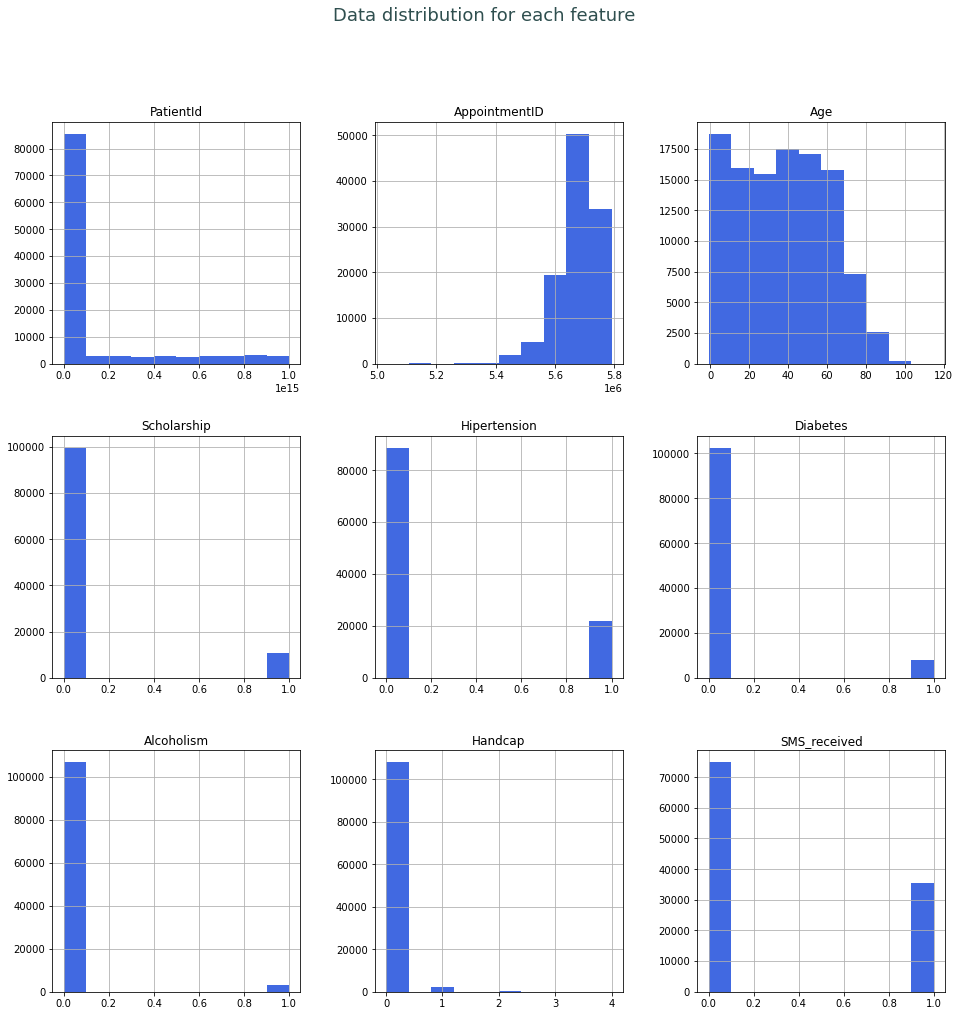

In [5]:
#draw an intial histogram to explore more of our data
df.hist(figsize=(16,16), color="royalblue"); 
plt.suptitle("Data distribution for each feature", fontsize = 18, color="darkslategrey");

>- **Age** is a bit skewed to the right which means that the data contains younger people than old.
>- Patients who suffer from alcholoism, diabetes or handicap are a minority.
>- Percentage of patients who have scholarship is just under 10%.
>- SMS was not sent to more than 60% of the patients!


### Data Cleaning


In [6]:
df.duplicated().any() #check for duplicates in the dataframe

False

In [7]:
df.columns = df.columns.str.lower() #convert columns names to lowercase
df.columns

Index(['patientid', 'appointmentid', 'gender', 'scheduledday',
       'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension',
       'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no-show'],
      dtype='object')

**Change dtypes for "scheduledday" and "appointmentday" columns to datetime**.

In [8]:
df["scheduledday"] = pd.to_datetime(df["scheduledday"])
df["appointmentday"] = pd.to_datetime(df["appointmentday"])
df.head(2)

,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no-show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No


In [9]:
def to_str(col_name):
    """This function converts the data type of columns in the dataframe to string
    ------------------------------------
    input:
    ------
   column name in the dataframe
    
    output:
    ------
    returns the passed column with its new dtype as string (object).
    """
    for column in df.columns:
        col_name = df[column].astype(str)
    return col_name

Convert **"patientid"** and **"appointmentid"** columns to string instead of simply dropping them as we won't need to perform any statistical analysis on them.

In [10]:
df.patientid = to_str(df['patientid'])
df.appointmentid = to_str(df['appointmentid'])

For less confusion & easy analysis, we will change **"no-show"** column to **"showed_up"** with 1 and 0 values for (showed up or didn't show up) respectively, instead of "Yes/No" no-show.

In [11]:
df["no-show"] = df["no-show"].replace({"Yes":0,"No":1})   #replace the Yes, No values with 0 and 1 
df["no-show"] = pd.to_numeric(df["no-show"])           #change the column dtype to int
df=df.rename(columns={"no-show":"showed_up"})          #rename the column to its new name "showed_up"

I assumed the **"handcap""** column refers to the disability of the patient and was named after a typo, so I changed it to **"handicap"**

In [12]:
df=df.rename(columns={"handcap":"handicap"})    

In [13]:
df.info()    #check for the new changes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   patientid       110527 non-null  object             
 1   appointmentid   110527 non-null  object             
 2   gender          110527 non-null  object             
 3   scheduledday    110527 non-null  datetime64[ns, UTC]
 4   appointmentday  110527 non-null  datetime64[ns, UTC]
 5   age             110527 non-null  int64              
 6   neighbourhood   110527 non-null  object             
 7   scholarship     110527 non-null  int64              
 8   hipertension    110527 non-null  int64              
 9   diabetes        110527 non-null  int64              
 10  alcoholism      110527 non-null  int64              
 11  handicap        110527 non-null  int64              
 12  sms_received    110527 non-null  int64              
 13  showed_up     

**Edit the negative values in the "age" column**.

In [14]:
df.age.describe()

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: age, dtype: float64

In [15]:
np.sort(df.age.unique())    #use numpy sort method to view the unique values in ascending order

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 102, 115],
      dtype=int64)

In [16]:
negative_age = df[df['age'] < 0]    #view the index of the negative value to drop it
negative_age.index

Int64Index([99832], dtype='int64')

In [17]:
df = df.drop([99832])    #drop the negative age value

In [18]:
df.age.min()             #check for changes

0

>**Now we're ready to explore our data after it was cleaned; The data now has:**
>- No duplicates
>- No Null values
>- No meaningless negative values
>- Proper columns names with proper datatypes

<a id='eda'></a>
## Exploratory Data Analysis


### Research Question 1: What is the percentage of those who showed up to their appointment and those who didn't ? 

In [19]:
df.showed_up.value_counts()

1    88207
0    22319
Name: showed_up, dtype: int64

In [20]:
no_show_num = df[df['showed_up']== 0].count()["patientid"]    #count of patients who didn't show up
showed_num = df[df['showed_up']== 1].count()["patientid"]     #count of patients who showed up
no_show_num , showed_num

(22319, 88207)

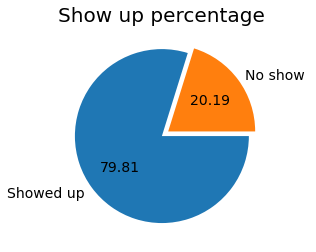

In [21]:
values_labels = ["Showed up" , "No show "]    #set labels for the pie chart
data = [showed_num , no_show_num]             #load the data
plt.pie(data, labels= values_labels, textprops={"fontsize" : 14}, autopct='%.2f', explode= (0,0.09), counterclock=False)    #assign the variables to create the pie chart and explode the No show percentage
plt.title("Show up percentage", fontsize=(20));    #set the title for our chart
plt.style.use("classic")           #use one of matplotlib available styles

>- **79.81%** of the patients showed up to their appointment
>- **20.19%** of the patients missed their appointment

### Research Question 2 : Does recieving SMS increases the chance of the patient showing up?


In [22]:
df['sms_received'].value_counts()     #view number of recieved sms & didn't recieve sms

0    75044
1    35482
Name: sms_received, dtype: int64

**Use seaborn countplot to plot a multiple bar chart to view how many showed up from those who recieved sms and those who didn't**

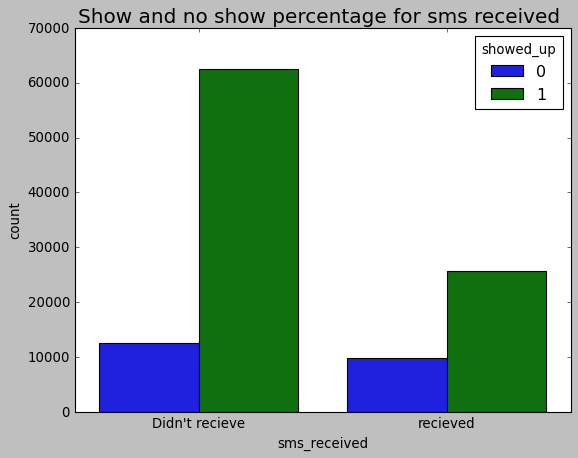

In [23]:
ax = sns.countplot(x=df.sms_received, hue=df.showed_up, data=df)     #load the data
ax.set_title("Show and no show percentage for sms received ", fontsize=(18));    #set the title and adjust the fontsize
x_labels = ["Didn't recieve", "recieved"]              #set the lables for the x axis
ax.set_xticklabels(x_labels);

Looks like who didn't revieve SMS showed up to their appointments more than those who recieved, that wasn't expected. Let's look at the **mean**

In [24]:
sms = df[df["sms_received"]==1]["showed_up"].mean()
no_sms = df[df["sms_received"]==0]["showed_up"].mean()
print("recieved sms mean '{}', no_sms mean '{}'".format(sms, no_sms))

recieved sms mean '0.7242545516036301', no_sms mean '0.8329646607323703'


**Let's visualize our result with a pie chart**

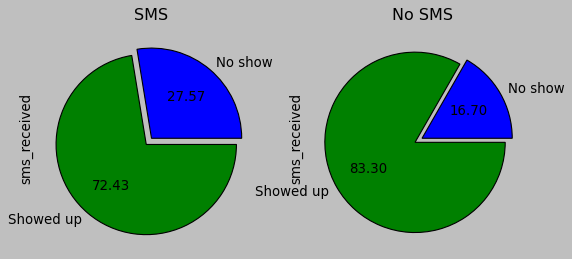

In [25]:
fig, axs = plt.subplots(1,2)   #set the number of figures and axis for our subplots
df[df["sms_received"]==1].groupby("showed_up")["sms_received"].count().plot(figsize=(8,8), kind="pie", autopct='%.2f', ax=axs[0], explode= (0,0.09), title="SMS", labels=("No show","Showed up"))
df[df["sms_received"]==0].groupby("showed_up")["sms_received"].count().plot(kind="pie", autopct='%.2f', ax=axs[1], explode= (0,0.09), title="No SMS", labels=("No show","Showed up"));

>This needs further investigation but we need more complete data like when the sms was sent for example. But for now, the percentage of showing up for those who didn't recieve SMS is **more** than those who recieved sms by around **10%**

### Research Question 3 : Does the chance of showing up depend on patient's gender?

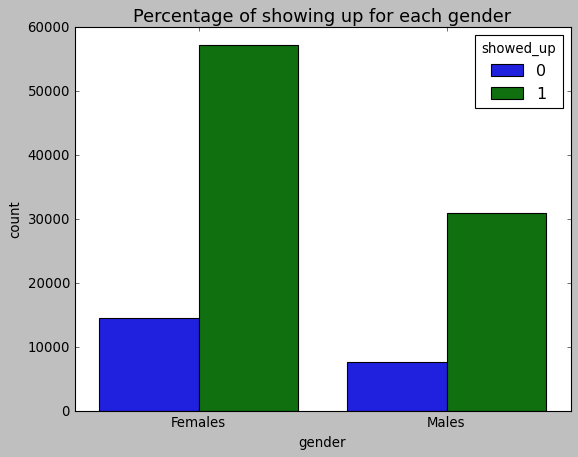

In [26]:
ax = sns.countplot(x=df.gender, hue=df.showed_up, data=df)
ax.set_title("Percentage of showing up for each gender", fontsize=(16));
x_labels = ["Females", "Males"]
ax.set_xticklabels(x_labels);

In [27]:
males = df[df["gender"]=="M"].groupby("showed_up")["gender"].count()    #use pandas groupby to view how many male showed up
males

showed_up
0     7725
1    30962
Name: gender, dtype: int64

In [28]:
females = df[df["gender"]=="F"].groupby("showed_up")["gender"].count()
females

showed_up
0    14594
1    57245
Name: gender, dtype: int64

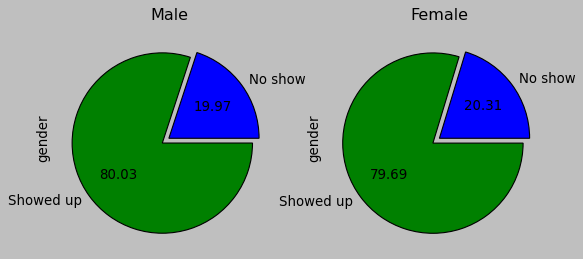

In [29]:
fig, axs = plt.subplots(1,2)
males.plot(figsize=(8,8), kind="pie", autopct='%.2f', ax=axs[0], explode= (0,0.09), title="Male", labels=("No show","Showed up"))
females.plot(figsize=(8,8), kind="pie", autopct='%.2f', ax=axs[1], explode= (0,0.09), title="Female", labels=("No show","Showed up"));

>**Percentage of showing up to the medical appointment for both genders is about the same**. 

### Research Question 4 : Does the chance of showing up to the appointment depend on the waiting duration between scheduled and appointment day?

In [30]:
df["duration"]=(df['appointmentday'].dt.normalize() - df['scheduledday'].dt.normalize())   #substract the appointment day from the sceduled day to get the waiting duration 
df.duration = df.duration.dt.days   #get the number of days from the date
df.duration.describe()      #view some statistical info for the new duration column

count    110526.000000
mean         10.183794
std          15.255034
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: duration, dtype: float64

We can see that there is a negetive value of (-6) as the minimum, Let's see where it came from.

In [31]:
df[df['duration'] < 0] 

,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handicap,sms_received,showed_up,duration
27033,Yes,Yes,M,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,38,RESISTÊNCIA,0,0,0,0,1,0,0,-1
55226,Yes,Yes,F,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,19,SANTO ANTÔNIO,0,0,0,0,1,0,0,-1
64175,Yes,Yes,F,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,22,CONSOLAÇÃO,0,0,0,0,0,0,0,-1
71533,Yes,Yes,F,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,81,SANTO ANTÔNIO,0,0,0,0,0,0,0,-6
72362,Yes,Yes,M,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,7,TABUAZEIRO,0,0,0,0,0,0,0,-1


Well, that doesn't make sense. Appointment day can't be made before the day it was scheduled on. Let's clean the duration column.

In [32]:
df = df[df['duration'] >= 0]   #assign only the postive values from the duration column into the orginal dataframe

In [33]:
df.groupby('showed_up')['duration'].mean()   #get the mean of waiting duration for those who showed up and those who didn't show up

showed_up
0    15.835484
1     8.754759
Name: duration, dtype: float64

>- We can see that the mean number of waiting days of those who showed up is around **9 days**.
>- And the mean number of waiting days of those who missed their appointments is around **16 days**.

**Let's visualize the percentage of showing up for each period to get more information** 

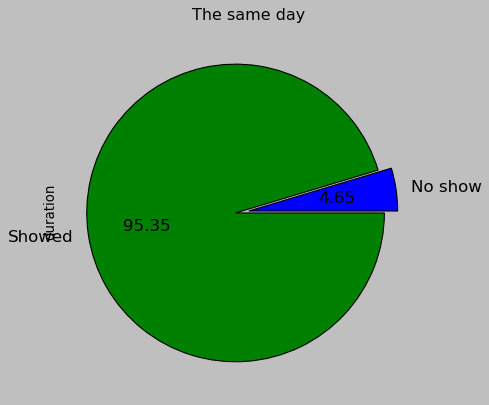

In [34]:
#count duration in the same day "0" grouped by the "showed_up" column then plot into pie chart
df[df["duration"] < 1].groupby("showed_up")["duration"].count().plot(figsize=(6,6), kind="pie", autopct='%.2f', explode=(0,0.09), title="The same day", labels= ("No show","Showed"), fontsize=(15));

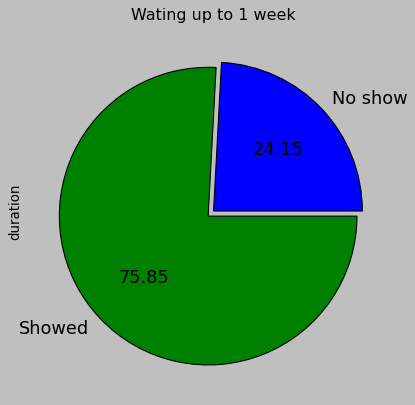

In [35]:
#count waiting duration from 1 to 7 days 
one_week_wait = df[(df["duration"] >= 1) & (df["duration"] <= 7)].groupby("showed_up")["duration"].count()
one_week_wait.plot(figsize=(6,6),kind="pie",autopct='%.2f', explode=(0,0.05), title="Wating up to 1 week", labels= ("No show","Showed"), fontsize=(16));

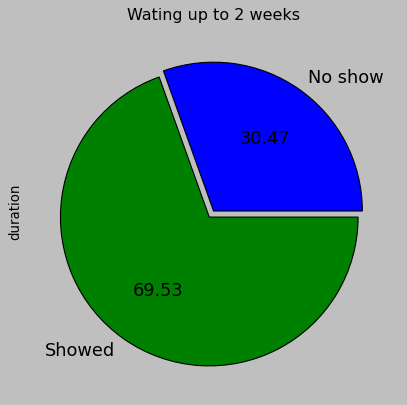

In [36]:
#count waiting duration from 8 to 14 days 
two_weeks_wait = df[(df["duration"] > 7) & (df["duration"] <= 14)].groupby("showed_up")["duration"].count()
two_weeks_wait.plot(figsize=(6,6),kind="pie",autopct='%.2f', explode=(0,0.05), title="Wating up to 2 weeks", labels= ("No show","Showed"), fontsize=(16));

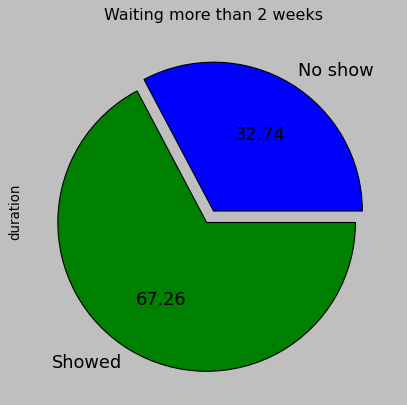

In [37]:
#count waiting duration for more than 14 days 
plus_two_weeks = df[df["duration"] > 14].groupby("showed_up")["duration"].count()
plus_two_weeks.plot(figsize=(6,6),kind="pie",autopct='%.2f', explode=(0,0.09), title="Waiting more than 2 weeks", labels= ("No show","Showed"), fontsize=(16));

>**We can see that the waiting duration is highly correlated with showing up, as the percentage of showing up highly increases if the duration is short**. 

### Research Question 5 : Does the chance of showing up to the appointment depend on the age of the patient?

In [38]:
df.age.describe()  #get another look at the statistics of the age column

count    110521.000000
mean         37.089386
std          23.109885
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: age, dtype: float64

We will divide the age into 4 categories: 
- **Children under  18 years**
- **Youth from 18 to 30**
- **Adults from 30 to 65**
- **Seniors above 65**

In [39]:
#get the mean for showing up for each age category
children = df[df["age"] < 18]["showed_up"].mean()
youth = df[(df["age"] >= 18) & (df["age"] <= 30)]["showed_up"].mean()
adults = df[(df["age"] > 30) & (df["age"] <= 65)]["showed_up"].mean()
seniors = df[df["age"] > 65]["showed_up"] .mean()
print("children mean={} , youth mean={}, adults mean={}, seniors mean={}".format(children, youth, adults, seniors))

children mean=0.7809920374022938 , youth mean=0.7539178082191781, adults mean=0.8107882852324928, seniors mean=0.8447368421052631


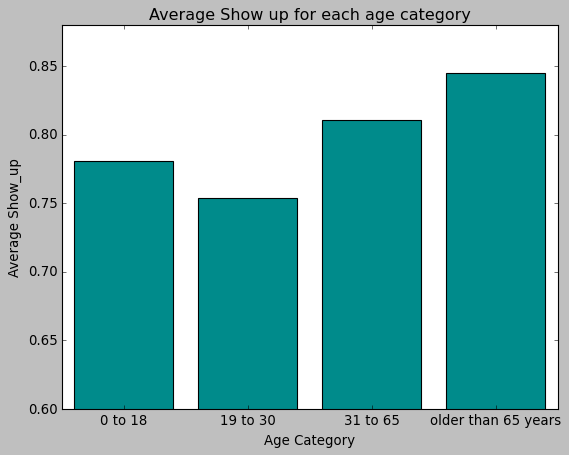

In [40]:
#plot a bar chart for each age category
locations = [1, 2, 3, 4]    #set locations for each bar
heights = [children, youth, adults, seniors]   #load the data as heights for the bars
labels = ["0 to 18","19 to 30","31 to 65","older than 65 years"]     #set the labels
plt.bar(locations, heights, tick_label=labels, color="darkcyan", edgecolor="black")
plt.ylim([0.6,0.88])    #extend the y axis limit to clearly present the difference 
plt.title('Average Show up for each age category')    #set the title for our chart
plt.xlabel('Age Category')
plt.ylabel('Average Show_up');

>**We can clearly see that older patients are more likely to attend their appointments**.

### Research Question 6 : Does having a chronic disease or a handicap among different age categories make the patients more committed to their appointment?

In [41]:
df.handicap.value_counts()   #count each value in the handicap column

0    108282
1      2040
2       183
3        13
4         3
Name: handicap, dtype: int64

I assumed that these numbers are the number of disabilites the patient might have.

**First**,
- We will divide the age into two categories: 
    - Under 65 and above 65
    
**Second**,

- We assign the values for each disease in each age category to **1** if he has the disease and **0** if he doesn't have it and the values for handicap to **0**  & **> 0**

**Then**,

- We groupby showed_up and count by age to calculate the attendance of each patient and create pie charts for the data.

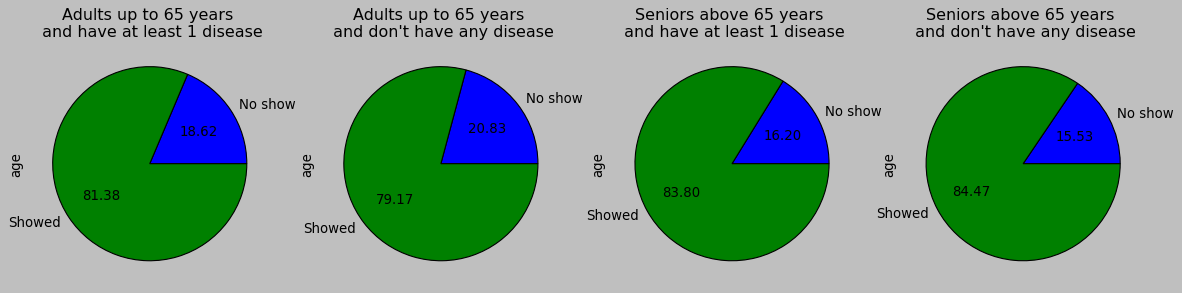

In [42]:
fig, axs = plt.subplots(1,4)

df[(df["age"] <= 65) & ((df["diabetes"]==1) | (df["hipertension"]==1) | (df["handicap"] > 0) | (df["alcoholism"]==1) )].groupby("showed_up")["age"].count().plot(figsize=(18,18), kind="pie", autopct='%.2f', ax=axs[0], title= "Adults up to 65 years \n and have at least 1 disease", labels= ("No show","Showed"));
df[(df["age"] <= 65) & ((df["diabetes"]==0) | (df["hipertension"]==0) | (df["handicap"]== 0) | (df["alcoholism"]==0) )].groupby("showed_up")["age"].count().plot(figsize=(18,18), kind="pie", autopct='%.2f', ax=axs[1], title= "Adults up to 65 years \n and don't have any disease", labels= ("No show","Showed"));

df[(df["age"] > 65) & ((df["diabetes"]==1) | (df["hipertension"]==1) | (df["handicap"] > 0) | (df["alcoholism"]==1) )].groupby("showed_up")["age"].count().plot(figsize=(18,18), kind="pie", autopct='%.2f', ax=axs[2], title= "Seniors above 65 years \n and have at least 1 disease", labels= ("No show","Showed"));
df[(df["age"] > 65) & ((df["diabetes"]==0) | (df["hipertension"]==0) | (df["handicap"]== 0) | (df["alcoholism"]==0) )].groupby("showed_up")["age"].count().plot(figsize=(18,18), kind="pie", autopct='%.2f', ax=axs[3], title= "Seniors above 65 years \n and don't have any disease", labels= ("No show","Showed"));

>Well, there is a slight difference in the showing up percentage for each group but it **isn't significant** by any means.

>So, we can state that attending the medical appointment **does not** depend on having one or more chronic disease/handicap. 

### Research Question 6 : What is the distribution of showing up among the neighbourhoods and what is the most frequent one?

In [43]:
df.neighbourhood.describe()

count             110521
unique                81
top       JARDIM CAMBURI
freq                7717
Name: neighbourhood, dtype: object

**JARDIM CAMBURI** is the most mentioned place in the data. Let's explore the other neighbourhoods.

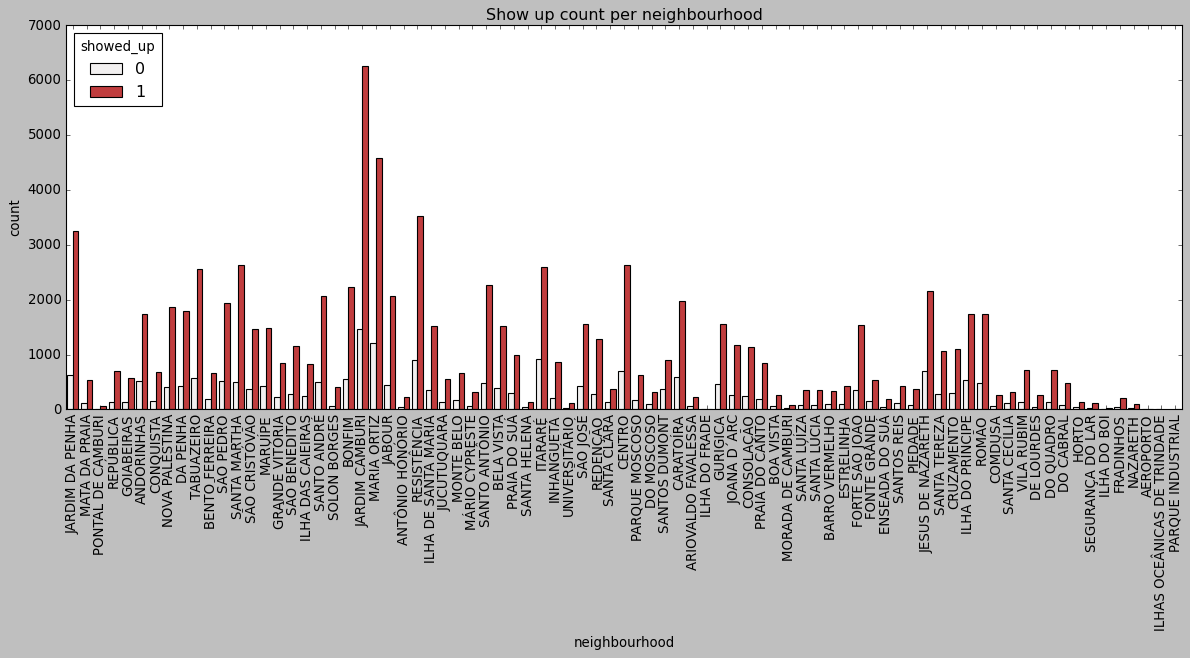

In [44]:
plt.figure(figsize=(18,6))
ax = sns.countplot(x=df.neighbourhood, hue=df.showed_up, color="tab:red")    #count the number of show ups for each neighbourhood by seaborn countplot
plt.xticks(rotation=90)     #rotate the x tick labels for a better presentation
ax.set_title("Show up count per neighbourhood");    #set a title for our figure

>We can see that most frequent neighbourhoods are **JARDIM CAMBURI**, **MARIA ORTIZ** & **RESISTENCIA**.

>We can have more insights about this if we collect more data about these neighbourhoods.

#### Finally, along with my basic analysis, I created a profile report with a quick data analysis using Pandas Profiling Package to explore possible trends among other features I might have missed in the dataframe or I wasn't able to perform by myself with my current skillset.

In [45]:
profile = ProfileReport(df, title="Pandas Profiling Report For a Quick Analysis", html={'style':{'full_width':True}})
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/29 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

<a id='conclusions'></a>
## Conclusions

>- **20.19%** of the patients don't show up to their appointment while **79.81%** do show up.
>- Older patients are **more likely to show up** to their appointments than younger patients.
>- Reminding the patients about their appointment by sms **does not increase** the chance of them showing up.
>- Percentage of showing up to the medical appointment for both males & females is **about the same**.
>- As the waiting duration between the scheduled and the appointment day **increases**, the chance of the patient **missing the appointment increases**.
>- Having a chronic disease or a handicap **does not** make the patient more committed to his appointment.
>- Most frequent neighbourhoods are **JARDIM CAMBURI, MARIA ORTIZ & RESISTENCIA**.

### Limitations
>**Data quality and tidiness issues such as**:
   
   >- **Accuracy and range constraints**: it doesn't make sense for an age to be 0 or a negative number and for the appointment        day to be before the schedueld day.
    
   >- **Completeness**: "sms_recieved" and "handcap" needs more clarification to be able to perform insightful analysis on them.
    
   >- **Data-Type Constraints**: "No-show" column was very messy and confusing as it has a negative meaning by the nature             of the name and has yes/no as values. Also, The "Id" columns were given an int dtype which doesn’t make them useful for the analysis if we calculated their mean or standard deviations so they should not be an integer.
        
 
>Most of the data is categorical which makes most of the plots and the statstical analysis meaningless to use.
